# Reports and plots — what the reviewer actually reads

A gate returns one of three verdicts. Two of them need no page:
<code>PASS</code> deploys and <code>BLOCKED</code> stops the build. The third,
`NEEDS_REVIEW`, hands the decision to a person — and until now that person got
a JSON blob.

This notebook covers the other half of a gate run: the charts, and the
self-contained HTML report they go into.

| Notebook | Covers |
|---|---|
| [01](01_binary_classification_sklearn.ipynb) | binary classification, and the library end to end |
| [02](02_multiclass_ordinal_sklearn.ipynb) | multiclass and ordinal underwriting |
| [03](03_regression_sklearn.ipynb) | regression — pricing, severity, frequency |
| [04](04_any_framework_classification.ipynb) | PyTorch and other non-sklearn models |
| [05](05_boosters_and_cli.ipynb) | XGBoost, LightGBM and the CLI |
| **06 (this one)** | plots, and the HTML report |

## The principle

We are not replacing your plotting library. A check draws a chart only where
it **collapses a distribution to a scalar and the shape is what you need to
judge**. Latency, cost and model-card completeness are genuinely scalars;
charting them would be decoration.

Fourteen of the twenty-six checks draw. The other twelve deliberately do not.

In [1]:
# %pip install -q "bdp-model-gate[structured,plots]"
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import bdp_model_gate
from bdp_model_gate.plots import plotting_available

logging.basicConfig(level=logging.WARNING, format="%(levelname)-8s %(name)s: %(message)s")
pd.set_option("display.width", 130)

print("bdp-model-gate", bdp_model_gate.__version__)
print("plotting available:", plotting_available())

bdp-model-gate 0.5.1


plotting available: True


## 1. A model with something to find

Two problems planted on purpose, because a chart of a clean model teaches
nothing:

- `distance_to_branch_km` is nearly determined by `region` — a **proxy** for
  an attribute the model is never given
- the published scores are bent away from the diagonal, so the model **ranks**
  acceptably while every probability it emits is wrong

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(42)
N = 2000

region = rng.choice(["Lagos", "Abuja", "Kano"], N, p=[0.45, 0.3, 0.25])
gender = rng.choice(["F", "M"], N, p=[0.48, 0.52])

# Branch network is dense in Lagos and sparse in Kano: a real operational fact,
# and a near-perfect stand-in for region.
distance = np.where(
    region == "Kano", rng.gamma(6.0, 2.4, N),
    np.where(region == "Abuja", rng.gamma(3.5, 1.6, N), rng.gamma(2.0, 1.2, N)),
)
income = rng.lognormal(11.6, 0.45, N) * pd.Series(region).map(
    {"Lagos": 1.35, "Abuja": 1.15, "Kano": 0.70}
).to_numpy()

X = pd.DataFrame({
    "monthly_income_ngn": income.round(2),
    "age": rng.integers(21, 65, N).astype(float),
    "months_employed": np.clip(
        rng.normal(np.where(region == "Kano", 30, 52), 26, N), 0, None
    ).round(),
    "debt_to_income": np.clip(rng.beta(2, 5, N) * 1.4, 0.01, 0.95).round(4),
    "distance_to_branch_km": distance.round(2),
})
protected = pd.DataFrame({"region": region, "gender": gender})

logit = (
    -0.2
    + 2.6e-6 * income
    + 0.011 * X["months_employed"].to_numpy()
    - 2.4 * X["debt_to_income"].to_numpy()
    - 0.045 * distance
    + 0.35 * (gender == "M")
)
y = (rng.random(N) < 1 / (1 + np.exp(-logit))).astype(int)

X_tr, X_va, y_tr, y_va, prot_tr, prot_va = train_test_split(
    X, y, protected, test_size=0.5, random_state=0, stratify=y
)
model = LogisticRegression(max_iter=3000).fit(X_tr, y_tr)

# The published score. Bent on purpose: ranking is untouched, every
# probability is now too high.
raw = model.predict_proba(X_va)[:, 1]
scores = np.clip(raw ** 0.55, 0.0, 1.0)

print(f"{len(X_va)} validation rows, base rate {y_va.mean():.3f}")
print(f"mean published score {scores.mean():.3f} against an observed rate of {y_va.mean():.3f}")

1000 validation rows, base rate 0.405
mean published score 0.595 against an observed rate of 0.405


In [3]:
from bdp_model_gate import ModelGate, StructuredGateContext
from bdp_model_gate.config import GateConfig

context = StructuredGateContext(
    model=model,
    X=X_va,
    y_true=y_va,
    y_pred=scores,
    protected_df=prot_va,
    model_card={
        "model_name": "retail_credit_v4",
        "owner": "Risk Analytics",
        "use_case": "credit_scoring",
        "legal_basis": "contract",
        "data_sources": ["core_banking", "credit_bureau"],
        "training_data_source": "core_banking extract, 2024-01 to 2026-06",
        "data_minimization_justification": (
            "Only fields with a documented predictive contribution are retained; "
            "protected attributes are held for monitoring, not scoring."
        ),
        "training_date": "2026-08-01",
        "explainability_method": "SHAP",
        "dpia_completed": True,
        "human_review_available": True,
    },
)

# min_score is lowered from the 0.8 default: this is a small synthetic book and
# the discrimination is beside the point here. The calibration flag is the one
# this notebook is about, and it survives either way.
credit_config = GateConfig()
credit_config.performance.min_score = 0.65

gate = ModelGate(config=credit_config)
report = gate.run(context)
print(report.summary())

Gate status: BLOCKED (1924ms, binary)
  roc_auc: 0.6876
  performance: 1 flag(s)
  compliance: 0 flag(s)
  security: 0 flag(s)
  fairness: 9 flag(s)


## 2. The reliability curve

The strongest case in the suite for a chart over a number.

Expected Calibration Error says *how far* the promises are from the outcomes.
It cannot say *where*. Two models scoring an identical ECE can be
miscalibrated in opposite directions — one confident only at the top of the
range, another wrong throughout — and those need different fixes.

Point **area** is the number of observations in the bin. A bin holding four
rows must not read as strongly as one holding four hundred.

CALIBRATION_RISK — expected calibration error=0.1900 (max 0.1) — predictions run high on average; reliability=0.0389, resolution=0.0260


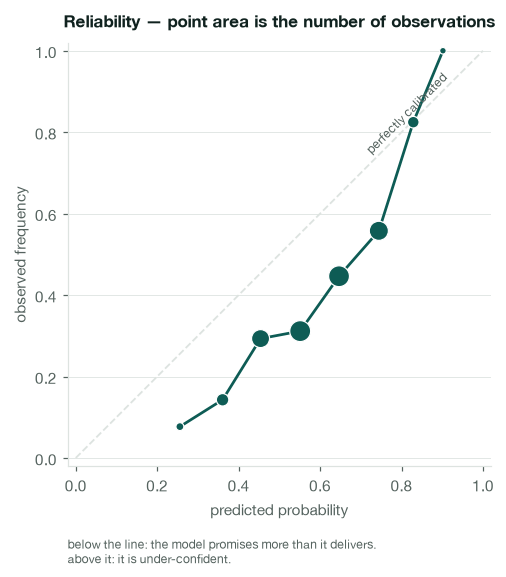

In [4]:
checks = {c.name: c for c in gate.checks}

calibration = checks["calibration"]
result = [r for r in report.results if r.check_name == "calibration"][0]
print(result.flag, "—", result.detail)

calibration.plot(context)
plt.show()

Every point sits **below** the diagonal: the model promises more than it
delivers, at every level of the score. That is a systematic offset, and it is
fixable by recalibration without retraining — which is exactly what the
detail line's *"predictions run high on average"* is telling you, and what a
lone ECE of the same magnitude could not distinguish from noise.

## 3. Composing into your own figure

Every `plot()` takes an optional `Axes` and returns **the same one**. That is
the whole contract: draw onto your canvas, hand it back.

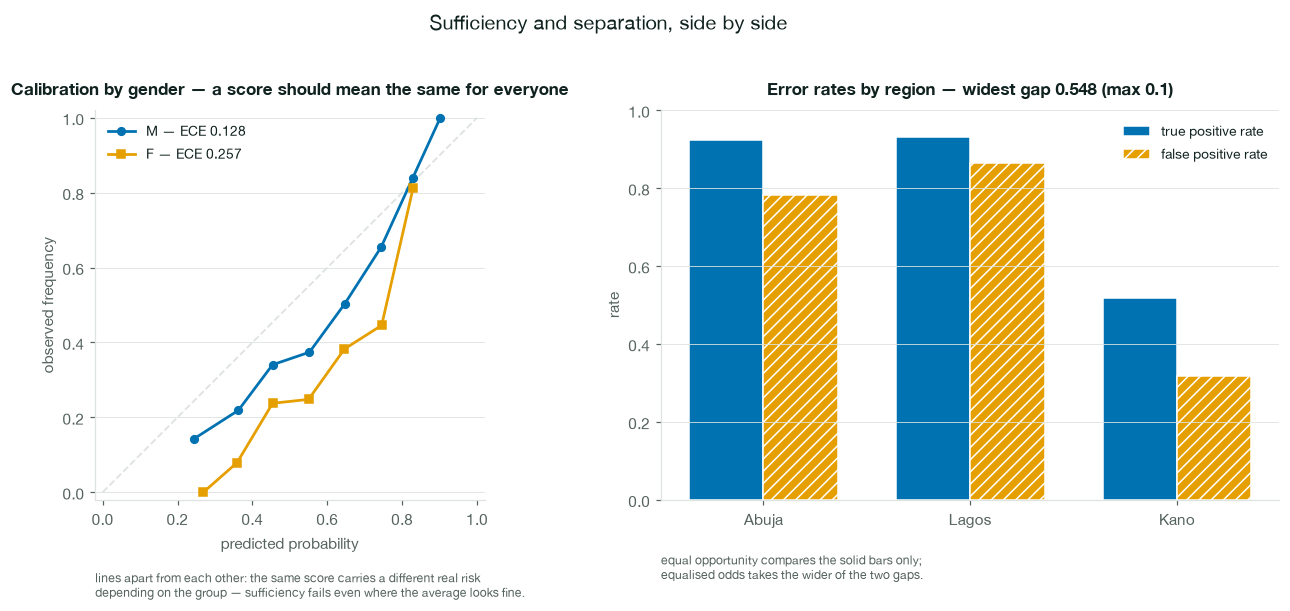

In [5]:
figure, (left, right) = plt.subplots(1, 2, figsize=(12.5, 5.4))

checks["subgroup_calibration"].plot(context, ax=left)
checks["equalised_odds"].plot(context, ax=right)

figure.suptitle("Sufficiency and separation, side by side", fontsize=13, y=1.02)
figure.tight_layout()
plt.show()

Two of the three fairness families in one figure — and note what they picked.

Each plot draws the attribute with the **largest gap for its own notion**, and
they landed on different ones. Sufficiency fails worst on **gender**: the two
reliability curves sit apart, so a score of 0.6 carries a different real risk
depending on who the applicant is. Separation fails worst on **region**: among
applicants who should be approved, Kano's true-positive rate is roughly half
Abuja's or Lagos's.

Those are two different problems, in two different places, with two different
remedies — and a single "fairness: 9 flags" line would hide both.

Fairness splits into **independence** (equal selection rates), **separation**
(equal error rates) and **sufficiency** (a score means the same thing for
everyone). Whenever base rates differ between groups these cannot all hold at
once (Kleinberg–Mullainathan–Raghavan 2016; Chouldechova 2017), so a tool
reporting one of them silently makes the choice for you.

## 4. The proxy heatmap

`proxy_correlation` produces one finding per (feature, attribute) pair. On a
modest model that is a forty-row table, and nobody scans forty rows looking
for the large number.

The grid the heatmap draws is the *same object* `run()` reported from — so a
cool cell can never sit beside a report line calling that pair a proxy.
Ringed cells are the ones that were flagged.

PROXY_RISK — distance_to_branch_km correlates with region (eta^2=0.632)


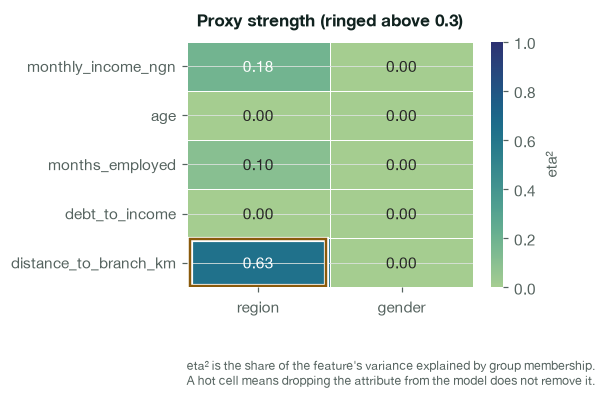

In [6]:
for r in report.results:
    if r.check_name == "proxy_correlation":
        print(r.flag, "—", r.detail)

checks["proxy_correlation"].plot(context)
plt.show()

This is the failure of *fairness through unawareness*: `region` was never
handed to the model, and `distance_to_branch_km` carries it anyway.

## 5. Does the verdict survive a different cutoff?

A parity difference is computed at one decision threshold, and a threshold is
a cliff edge. The sweep asks the question a reviewer actually has: **is this
pass robust, or did the cutoff happen to land in a good place?**

The marked point on each line is the verdict in the report — it is not
recomputed for the chart, so the curve passes through its own finding by
construction.

DISPARITY_RISK — region: demographic parity diff=0.518
OK — gender: demographic parity diff=0.002


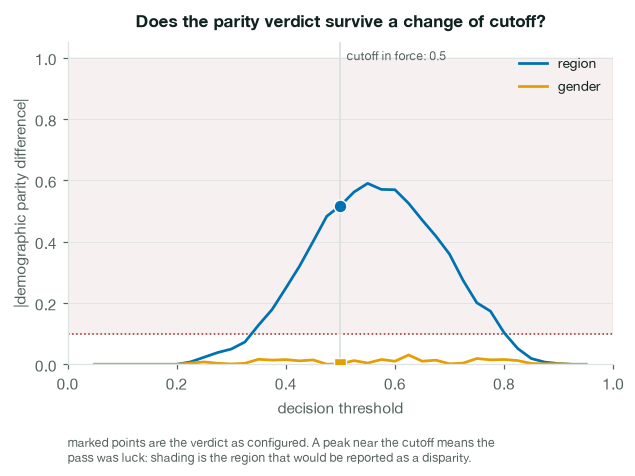

In [7]:
for r in report.results:
    if r.check_name == "disparate_impact":
        print(r.flag, "—", r.detail)

checks["disparate_impact"].plot(context)
plt.show()

## 6. Pricing — two charts a single number cannot replace

Switch to a regression context: a motor premium against a per-policy expected
loss. Charging more in a higher-loss segment is **risk-based pricing**, not
discrimination. Charging a higher *margin over expected loss* is the thing
worth finding, and it needs `expected_loss` to be visible at all.

In [8]:
expected_loss = np.clip(38_000 + 1_050 * distance + rng.normal(0, 4_500, N), 6_000, None)
# A regional loading that has nothing to do with cost — the finding to surface.
loading = np.where(region == "Kano", 0.24, 0.0)
premium = expected_loss * (1.16 + loading) + rng.normal(0, 3_000, N)
realised = expected_loss * rng.gamma(9.0, 1 / 9.0, N)

pricing_X = X[["distance_to_branch_km", "monthly_income_ngn", "months_employed"]]
pricing = StructuredGateContext(
    model=None,
    X=pricing_X,
    y_true=realised,
    y_pred=premium,
    protected_df=protected,
    expected_loss=expected_loss,
    predict_fn=lambda frame: premium[: len(frame)],
    task="regression",
)

# Gated on MAE, not R²: realised loss scatters around any premium by nature —
# that is what insurance is — so R² would flag a perfectly sound pricing model.
pricing_config = GateConfig()
pricing_config.performance.metric = "mae"
pricing_config.performance.max_error = 20_000

pricing_gate = ModelGate(config=pricing_config)
pricing_report = pricing_gate.run(pricing)
print(pricing_report.summary())

Gate status: NEEDS_REVIEW (3096ms, regression)
  mae: 16158.2399
  performance: 0 flag(s)
  compliance: 0 flag(s)
  security: 0 flag(s)
  fairness: 5 flag(s)


calibration_parity — region: prediction bias spans 6,093.85 (Lagos, under-predicted) to 20,490.53 (Kano, over-predicted) — 31.9% of the overall actual mean 45,120.36 

loss_ratio_parity — region: premium-to-expected-loss ratio spans 1.155 (Abuja) to 1.402 (Kano) — 20.2% of the overall ratio 1.222; Kano carries the higher margin over its own expected cost 



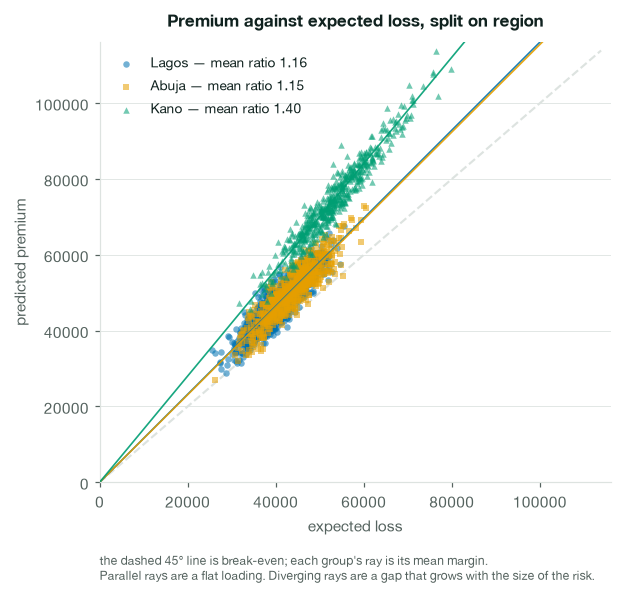

In [9]:
pricing_checks = {c.name: c for c in pricing_gate.checks}

for r in pricing_report.results:
    if r.check_name in ("loss_ratio_parity", "calibration_parity") and not r.is_ok:
        print(r.check_name, "—", r.detail, "\n")

pricing_checks["loss_ratio_parity"].plot(pricing)
plt.show()

The dashed 45° line is break-even; each group's ray is its own mean margin.
**Parallel rays would be a flat loading** — arguable, but one decision.
Rays that diverge mean the gap grows with the size of the risk, which is a
different finding with a different remedy. The scalar in the report says
*how big*; only the scatter says *which*.

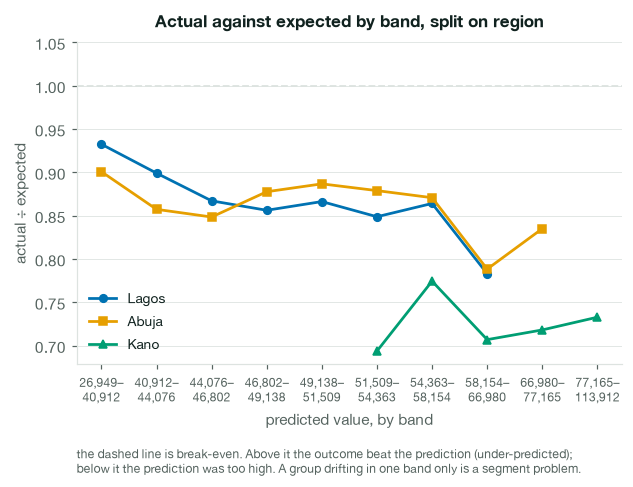

In [10]:
pricing_checks["calibration_parity"].plot(pricing)
plt.show()

RMSE says "wrong by 25,000". Actual-over-expected by band says "under-priced
in the top decile, and only for one group". Bands are quantiles of the
prediction **shared across groups**, so the lines are comparable — per-group
edges would put different business at each x position.

## 7. Ordinal decisions: where the errors land

`quadratic_kappa` penalises rank distance squared and then reports one number,
which hides *direction* entirely. A model that sends accepts to `decline` and
one that sends them to `refer` can score alike, and only one of those is a
scandal.

OK — quadratic_kappa=0.6978 (min 0.45)


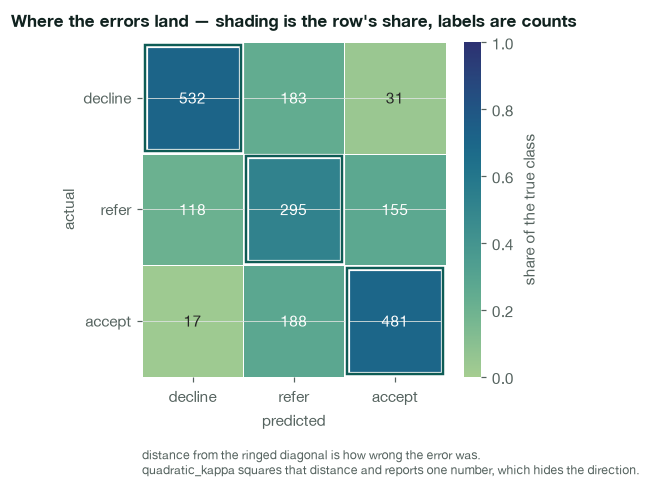

In [11]:
from bdp_model_gate.structured.performance import PerformanceThresholdCheck

order = ["decline", "refer", "accept"]


def scorecard(frame):
    """A three-band underwriting rule over the same drivers as the scorecard."""
    return (
        2.6e-6 * frame["monthly_income_ngn"].to_numpy()
        + 0.011 * frame["months_employed"].to_numpy()
        - 2.4 * frame["debt_to_income"].to_numpy()
        - 0.045 * frame["distance_to_branch_km"].to_numpy()
    )


cuts = np.quantile(scorecard(X), [1 / 3, 2 / 3])


def band(values):
    return np.asarray(order)[np.clip(np.digitize(values, cuts), 0, 2)]


# The truth is the band the applicant turned out to deserve; the model sees a
# noisier version of the same signal.
decisions = band(scorecard(X))
outcomes = band(scorecard(X) + rng.normal(0, 0.55, N))

ordinal_config = GateConfig()
ordinal_config.performance.metric = "quadratic_kappa"
ordinal_config.performance.min_score = 0.45

ordinal = StructuredGateContext(
    model=None,
    X=X,
    y_true=outcomes,
    y_pred=decisions,
    protected_df=protected,
    predict_fn=lambda frame: band(scorecard(frame)),
    class_order=order,
    task="multiclass",
)

# Just the one check: this section is about the heatmap, and running the full
# suite here would spend a page on findings covered elsewhere.
scoring = PerformanceThresholdCheck(ordinal_config.performance)
(ordinal_result,) = ModelGate(checks=[scoring]).run(ordinal).results
print(ordinal_result.flag, "—", ordinal_result.detail)

scoring.plot(ordinal)
plt.show()

Rows are the truth, columns the prediction, both in **your** `class_order` —
which is what makes distance from the ringed diagonal readable as severity.

A binary confusion matrix is *not* drawn: four numbers the detail line already
carries. Charting them would be decoration.

## 8. The one plot that costs money

`adversarial_robustness` re-scores a sample at each epsilon, which against a
metered endpoint is a real bill. So the sweep is **opt-in**: by default
`plot()` returns `None` and the report omits the chart.

default plot(): None
OK — flip rate under gradient-directed perturbation=0.0250 (max 0.05)


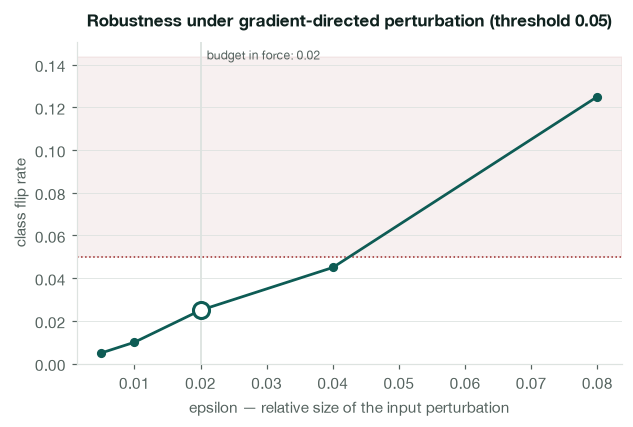

In [12]:
from bdp_model_gate.structured.security import AdversarialRobustnessCheck

default_check = AdversarialRobustnessCheck()
print("default plot():", default_check.plot(context, default_check.run(context)))

sweeping = AdversarialRobustnessCheck(plot_sweep=True)
(robustness,) = sweeping.run(context)
print(robustness.flag, "—", robustness.detail)

sweeping.plot(context, [robustness])
plt.show()

Shape matters here more than level. This one decays roughly linearly and
crosses the threshold at about **twice** the configured budget: the pass at
0.02 is a genuine pass with a little room, not a coincidence.

The alternative — **flat, then a collapse** just outside the budget — would
plot as a cliff, and it is a materially different risk, because someone will
eventually push past 0.02. The single number at the marked point is identical
in both cases.

### The trap this release was built around

This check scores a **subsample** for speed. A chart that re-sampled would
illustrate different rows than the verdict came from — a picture quietly
contradicting the number beside it.

Three things prevent it, and none of them is "write more tests":

1. `stable_sample` selects rows by their **contents**, not their position, so
   permuting the input cannot change which rows are scored.
2. The perturbation core lives in one method, `_measure(context, epsilon)`,
   which both `run()` and `plot()` call. The curve passes through the reported
   point by construction, not by agreement.
3. The suite reads values **back off the Axes** and asserts them against
   `metadata`.

Worth proving rather than claiming:

In [13]:
epsilon = sweeping.config.adversarial_epsilon

# Read the curve back off the figure the check drew.
axes = sweeping.plot(context, [robustness])
curve = next(ln for ln in axes.lines if len(ln.get_xdata()) > 2)
xs, ys = list(curve.get_xdata()), list(curve.get_ydata())
plt.close(axes.get_figure())

print(f"reported flip rate      : {robustness.metadata['flip_rate']}")
print(f"curve at epsilon={epsilon:<6}: {ys[xs.index(epsilon)]}")

# And again with the rows shuffled.
order_ix = np.random.default_rng(9).permutation(len(X_va))
shuffled = StructuredGateContext(
    model=model,
    X=X_va.iloc[order_ix].reset_index(drop=True),
    y_true=np.asarray(y_va)[order_ix],
    y_pred=scores[order_ix],
    protected_df=prot_va.iloc[order_ix].reset_index(drop=True),
)
(shuffled_result,) = sweeping.run(shuffled)
print(f"after permuting the rows: {shuffled_result.metadata['flip_rate']}")

reported flip rate      : 0.025
curve at epsilon=0.02  : 0.025
after permuting the rows: 0.025


## 9. The report

`report.to_html()` writes **one self-contained file**. No script, no
stylesheet, no font, no image fetched from anywhere: a governance record gets
emailed, filed and reopened years later, and every external reference is a way
for it to stop rendering.

Charts are inlined as SVG rather than `<img src="data:...">`, so they inherit
the page's CSS — one render reads correctly in light and dark — and stay sharp
in print.

In [14]:
from pathlib import Path

page = report.to_html("gate-report.html", title="Retail credit scorecard v4")

print(f"{len(page) / 1024:,.0f} KB, {page.count('<svg')} charts inlined")
for forbidden in ("<script", "<link", "@import", 'src="http', 'href="http', "data:image"):
    assert forbidden not in page, forbidden
print("no scripts, no stylesheets, no fonts, no remote images, no rasterised charts")
print("\nopen gate-report.html in any browser — it needs no network")

394 KB, 5 charts inlined
no scripts, no stylesheets, no fonts, no remote images, no rasterised charts

open gate-report.html in any browser — it needs no network


The page carries the verdict in plain words, every finding with its evidence
one click away, and each check's chart beneath the numbers it explains.
`NOT_APPLICABLE` results are included on purpose: what was *skipped and why*
is part of the record, and a report that quietly omits them lets a reader
assume coverage that never happened.

### It degrades; it does not fail

Three ways the charts can be lost, and none of them loses a finding:

In [15]:
# 1. Turned off explicitly.
print("include_plots=False :", "<svg" in report.to_html(include_plots=False))

# 2. A report rebuilt from JSON has no data to plot from.
from bdp_model_gate.reporting import render_html

print("no context         :", "<svg" in render_html(report, checks=None, context=None))

# 3. A plot that raises costs its own chart and nothing else.
from bdp_model_gate.core.base import BaseCheck, CheckResult


class Temperamental(BaseCheck):
    name = "temperamental_check"
    category = "security"
    blocking = False

    def run(self, ctx):
        return [CheckResult(self.name, self.category, "OK", "this finding survives", False)]

    def plot(self, ctx, results=None, ax=None):
        raise RuntimeError("the renderer fell over")


broken = ModelGate(checks=[Temperamental()]).run(context).to_html()
print("finding kept       :", "this finding survives" in broken)
print("chart replaced by  :", "chart unavailable" in broken)

WARNING  bdp_model_gate.reporting: plot failed for check=temperamental_check: RuntimeError('the renderer fell over')


include_plots=False : False
no context         : False
finding kept       : True
chart replaced by  : True


Without the `[plots]` extra installed at all, `plot()` raises
`GateConfigurationError` naming the extra and the report renders text-only —
the same way `shap` and `fairlearn` already degrade.

### What is deliberately not in the report

`ModelGate.run` attaches the checks and the context to the `GateReport` so
`to_html()` works without you re-supplying them. Both are excluded from the
constructor, the repr, equality and `to_dict()`.

A report is an archival record of **findings**. Neither your data nor your
model belongs in one.

In [16]:
payload = report.to_dict()
print("keys:", sorted(payload))
assert "_checks" not in payload and "_context" not in payload
print("\nthe JSON carries findings only — safe to file, safe to ship")

Path("gate-report.html").unlink(missing_ok=True)

keys: ['gate_status', 'model_auc', 'model_metric', 'model_score', 'n_flags', 'results_by_category', 'task', 'total_duration_ms']

the JSON carries findings only — safe to file, safe to ship


## 10. Drawing your own check

Override `plot()`. There is nothing to register — the renderer calls it on
every check and uses whatever comes back, so an override is the whole opt-in.

THIN_FILE_RISK — region: thin-file rate spans 15.6% across groups
OK — gender: thin-file rate spans 1.8% across groups


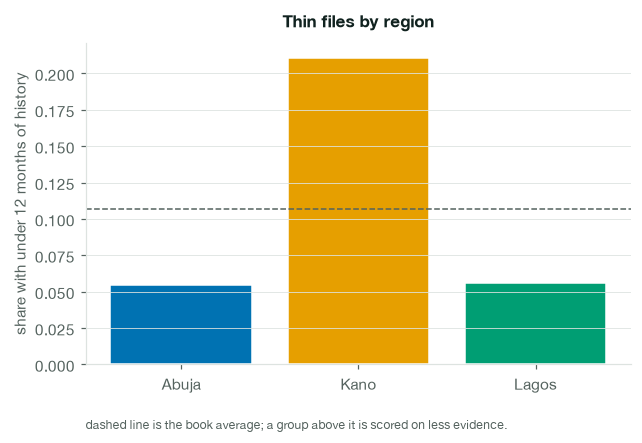

In [17]:
from bdp_model_gate.plots import require_plotting, worst_result
from bdp_model_gate.plots.style import caption, categorical, new_axes, verdict_colour


class ThinFileRateCheck(BaseCheck):
    """Share of each group with too little history to score properly."""

    name = "thin_file_rate"
    category = "fairness"
    blocking = False

    def __init__(self, max_gap: float = 0.10, months: float = 12.0):
        self.max_gap, self.months = max_gap, months

    def _rates(self, ctx):
        thin = ctx.X["months_employed"] < self.months
        return {
            attr: thin.groupby(ctx.protected_df[attr].values).mean().to_dict()
            for attr in ctx.protected_df.columns
        }

    def run(self, ctx):
        results = []
        for attr, rates in self._rates(ctx).items():
            gap = max(rates.values()) - min(rates.values())
            results.append(
                CheckResult(
                    self.name, self.category,
                    "THIN_FILE_RISK" if gap > self.max_gap else "OK",
                    detail=f"{attr}: thin-file rate spans {gap:.1%} across groups",
                    blocking=self.blocking,
                    metadata={"protected_attr": attr, "rate_gap": round(gap, 4),
                              "group_rate": {k: round(v, 4) for k, v in rates.items()}},
                )
            )
        return results

    def plot(self, ctx, results=None, ax=None):
        require_plotting()
        results = self.run(ctx) if results is None else results
        finding = worst_result(results, "rate_gap")
        if finding is None:
            return None                      # nothing to draw is not an error

        rates = finding.metadata["group_rate"]
        ax = new_axes(ax)
        ax.bar(list(rates), list(rates.values()),
               color=categorical(len(rates)), edgecolor="white")
        ax.axhline(np.mean(list(rates.values())), linestyle="--", linewidth=1.0,
                   color=verdict_colour("NOT_APPLICABLE"))
        ax.set_ylabel("share with under 12 months of history")
        ax.set_title(f"Thin files by {finding.metadata['protected_attr']}")
        caption(ax, "dashed line is the book average; a group above it is scored on less evidence.")
        return ax


custom = ThinFileRateCheck()
for r in custom.run(context):
    print(r.flag, "—", r.detail)

custom.plot(context)
plt.show()

Four rules for a `plot()` of your own:

1. **Return `None` rather than an empty frame** when the inputs are missing.
   Most checks have nothing to draw most of the time.
2. **Never raise.** The report catches it and prints a note, but the reviewer
   still loses the chart.
3. **Recompute; do not store.** Small per-group dicts in `metadata` are
   *findings* and stay. Anything array-sized — bin edges, curve points,
   per-row SHAP — is recomputed at plot time, so the archived JSON does not
   carry presentation data most consumers never read.
4. **Seaborn's axes-level functions only** (`barplot`, `lineplot`, `heatmap`,
   `scatterplot`, `histplot`). The figure-level ones (`relplot`, `catplot`,
   `displot`) build their own Figure and ignore `ax`, which breaks the
   composition contract.

## 11. Style, and why it is not decoration

Two colour systems, kept strictly apart:

- **Semantic** — pass / review / blocked. These *mean* something, and a group
  must never borrow them. A green bar that happens to be group A, sitting
  beside a green verdict pill, is a misread waiting to happen.
- **Categorical** — for groups. Okabe–Ito, the standard colour-blind-safe
  qualitative palette, because roughly 8% of men have some colour vision
  deficiency and a gate report is a document a regulator may read.

And colour is never the *only* encoding — series carry marker shapes, paired
bars carry hatching, flagged heatmap cells are ringed. These reports get
printed in greyscale.

In [18]:
from bdp_model_gate.plots.style import CATEGORICAL, MARKERS, VERDICT_COLOURS

print("verdict (semantic):", VERDICT_COLOURS)
print("groups (categorical):", CATEGORICAL[:4], "paired with", MARKERS[:4])
assert not set(CATEGORICAL) & set(VERDICT_COLOURS.values()), "a group borrowed a verdict hue"
print("\nno overlap — a group can never be coloured like a verdict")

verdict (semantic): {'PASS': '#2e6b43', 'OK': '#2e6b43', 'NEEDS_REVIEW': '#8a5a0b', 'BLOCKED': '#9b2c2c', 'NOT_APPLICABLE': '#55635f'}
groups (categorical): ['#0072b2', '#e69f00', '#009e73', '#cc79a7'] paired with ['o', 's', '^', 'D']

no overlap — a group can never be coloured like a verdict


## Summary

| Plot | Check | What the number cannot say |
|---|---|---|
| Reliability curve | `calibration` | two models with the same ECE can be wrong in opposite directions |
| Reliability per group | `subgroup_calibration` | where the aggregate hides a minority |
| TPR/FPR bars | `equalised_odds` | which notion is failed, and by how much |
| eta-squared heatmap | `proxy_correlation` | replaces a forty-row table |
| Threshold sweep | `disparate_impact` | whether the verdict survives a different cutoff |
| Actual-vs-expected by band | `calibration_parity` | *where* in the book the pricing is wrong |
| Loss-ratio scatter | `loss_ratio_parity` | whether the margin gap is flat or grows |
| Ordinal confusion | `performance_thresholds` | the direction of the error |
| Robustness sweep | `adversarial_robustness` | a cliff versus a slope |

Three things worth carrying away:

1. **An `Axes` in, the same `Axes` out.** These compose into your figures and
   can be restyled. This library does not replace your plotting stack.
2. **A chart may not contradict the number beside it.** Where a plot and a
   finding could diverge, they are made to share one implementation — and a
   test reads the drawn value back and asserts it.
3. **The report degrades, it never fails.** No extra, no context, or a
   renderer that throws: you lose a chart, never a finding.

Next: [`web/docs/reference/plots.md`](https://vanjy-eng.github.io/model-gate/docs/reference/plots/)
for the full API.